
<div style="text-align: center; background-color: lightblue; padding: 15px;">
    <p style="text-align: center;">بسم الله، والحمد لله، والصلاة والسلام على رسول الله وعلى آله وصحبه</p>
</div>

# I- NECESSARY TOOLS

In [1]:
from me_r_sy.ingestion.grib import get_grib , get_var
from me_r_sy.visualization.plots import Plotter
from me_r_sy.analysis.statistics import Statistics
import geopandas as gpd
import numpy as np
import yaml
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import calendar
import argparse
import json

# II- READ DATA

In [2]:
# read the config file
config_file = "/home/muhammed/METEO-REPORTING-SYSTEM/ME_R_SY/config/config_2018_01.yml"
with open(config_file , "r") as f :
    config = yaml.safe_load(f)

In [4]:
year       = config["date"]["year"]
month      = config["date"]["month"]
input_dir  = config["data"]["input"] 
ref_dir    = f"{input_dir}/reference_1991_2020.grib"
output_dir = config["data"]["output"] 
shp_path   = config["data"]["shapefile"]
year       = config["date"]["year"]
month      = config["date"]["month"]

In [5]:
# read the shapefile
grib_path = f"{input_dir}/input_{year}_{month:02d}.grib"

ref_path  = f"{input_dir}/reference_1991_2020.grib"

cmap_dict = {"2t": "RdYlBu_r", "tp": "GnBu", "msl": "viridis", "w": "YlOrRd"}

cmap_dict_anom = {"2t": "bwr", "tp": "PuOr", "msl": "BrBG", "w": "RdGy"}

shp_path = "/home/muhammed/METEO-REPORTING-SYSTEM/ME_R_SY/data/regions/regions.shp"

shp = gpd.read_file(shp_path)
ds        = get_grib(grib_path)
ds_ref    = get_grib(ref_path)
ref_mean  = list(map(lambda ds : Statistics.ref_avg(ds , month) , ds_ref))
month_range = calendar.monthrange(year , month)[1]

In [6]:
variables = get_var(ds)
ref_variables = get_var(ref_mean)
ref_variables["tp"] = ref_variables["tp"] * month_range

In [7]:
Stats = Statistics()
Plot = Plotter(shp , cmap_dict , cmap_dict_anom)
statistics  = Stats.calculate_statistics(variables = variables)
daily_stats = Stats.calculate_daily(variables)
anomaly     = Stats.calculate_anomaly(statistics , ref_variables)

In [18]:
message = {

    "studied_period": {
        "year": int(year),
        "month": int(month)
    },

    "reference_period": {
        "start_year": 1991,
        "end_year": 2020
    },

    "temperature": {
        "maximum": {
            "value": float(daily_stats["max"]["t2m"]["values"]mean().values),
            "day": str(t_max_day.values),
            "latitude": float(t_max_lat.item()),
            "longitude": float(t_max_lon.item())
        },
        "anomaly": float(t_anom.mean().values)
    },

    "wind_speed": {
        "maximum": {
            "value": float(w_max.mean().values),
            "day": str(w_max_day.values),
            "latitude": float(w_max_lat.item()),
            "longitude": float(w_max_lon.item())
        },
        "anomaly": float(w_anom.mean().values)
    },

    "total_precipitation": {
        "maximum": {
            "value": float(tp_max.max().values),
            "day": str(tp_max_day.values),
            "latitude": float(tp_max_lat.item()),
            "longitude": float(tp_max_lon.item())
        },
        "anomaly": float(tp_anom.mean().values)
    },

    "pressure": {
        "anomaly": float(p_anom.mean().values)
    }
}

NameError: name 't_max' is not defined

In [19]:
message_json = json.dumps(
    message , 
    indent = 4
)

print(message_json)

NameError: name 'message' is not defined

# III- VIZUALISATION

## III-1 MONTHLY AVERAGE

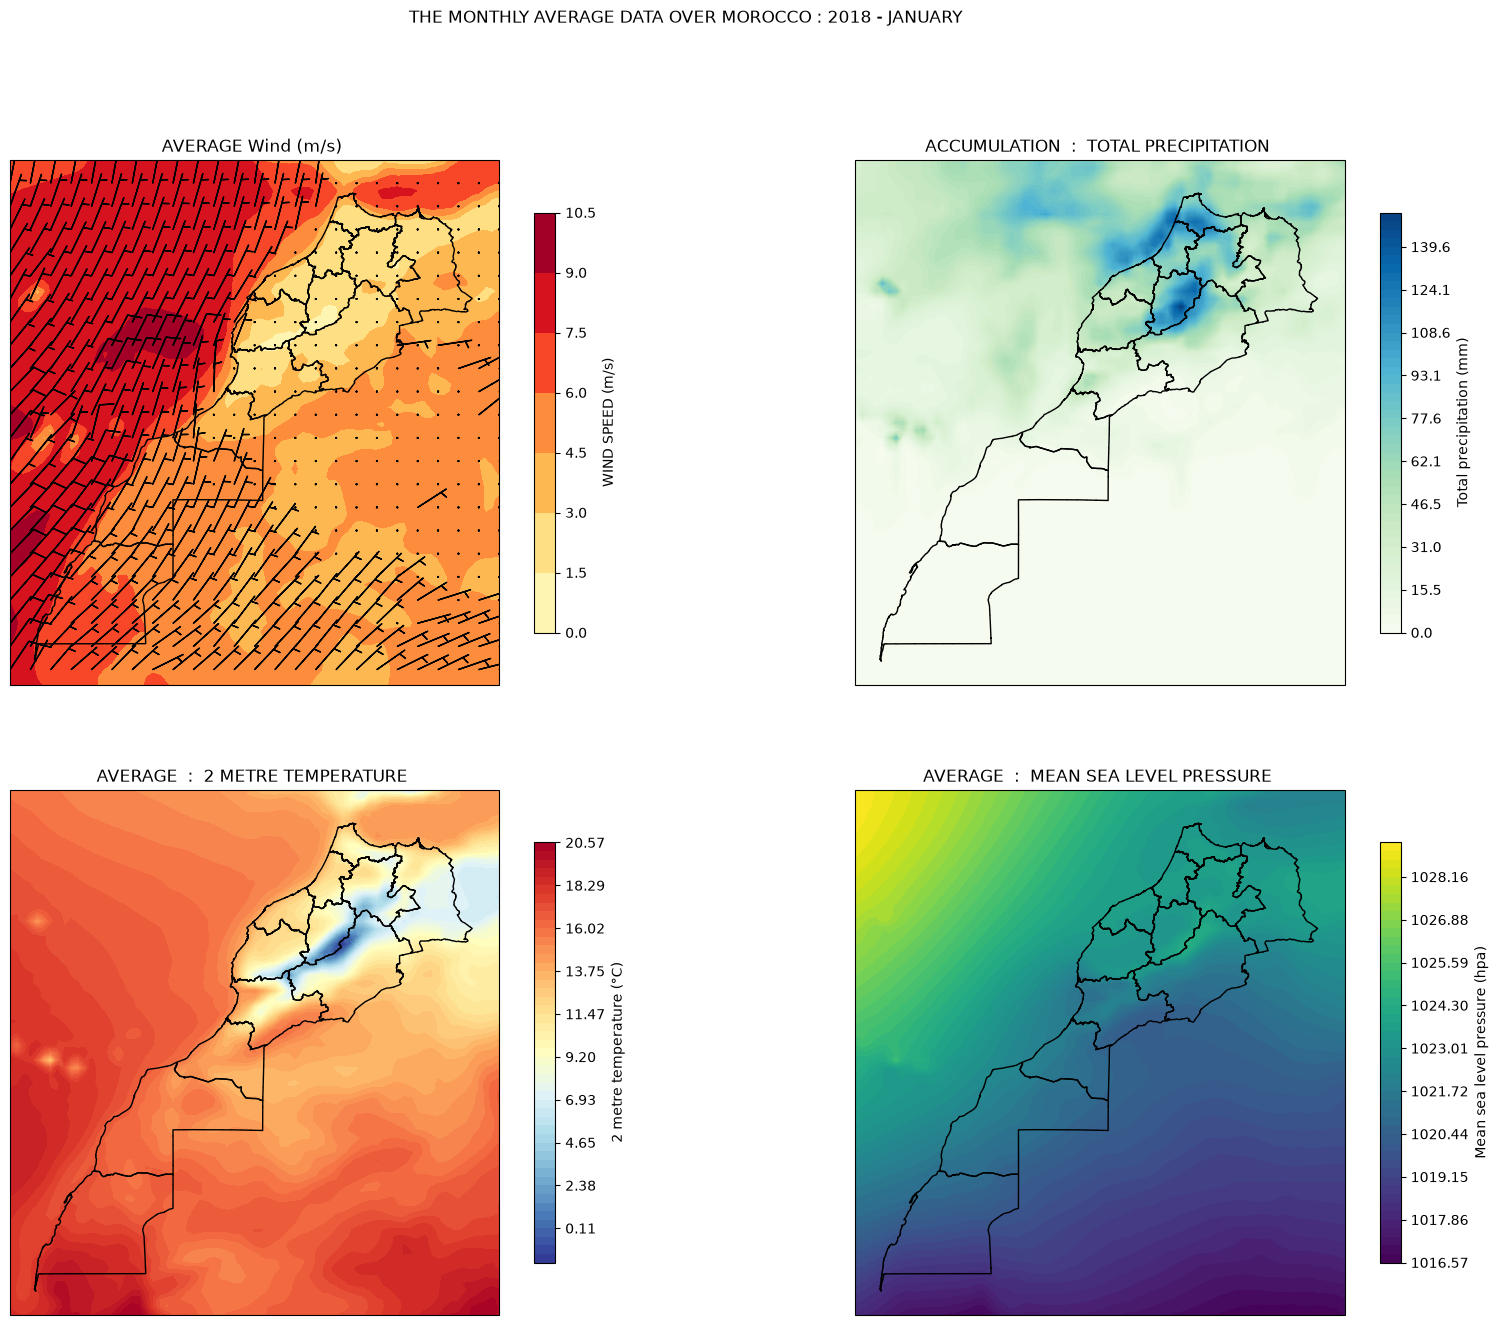

In [8]:
Plot.plot_monthly_avg(statistics , year , month , output_dir)

## III-2 MONTHLY MAX

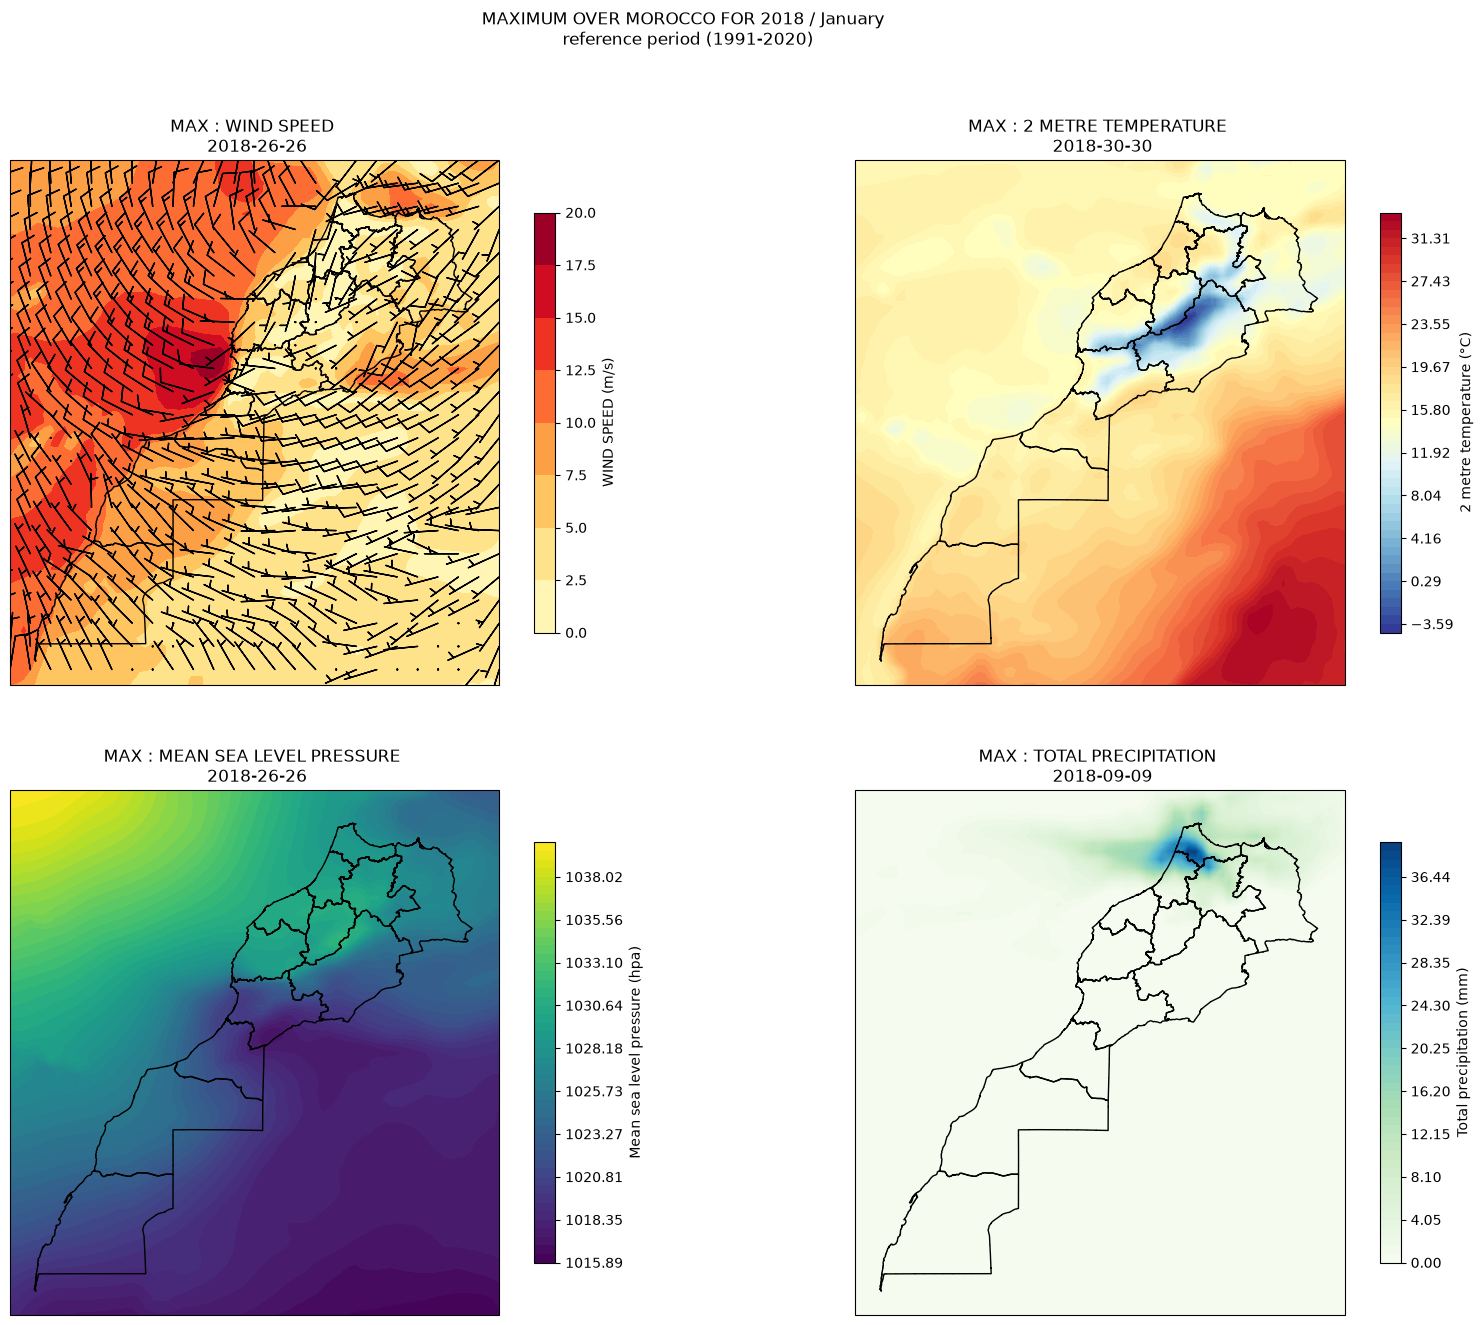

In [9]:
Plot.plot_max_days(daily_stats , "max" , year , month , output_dir)

## III-3 MONTHLY MIN

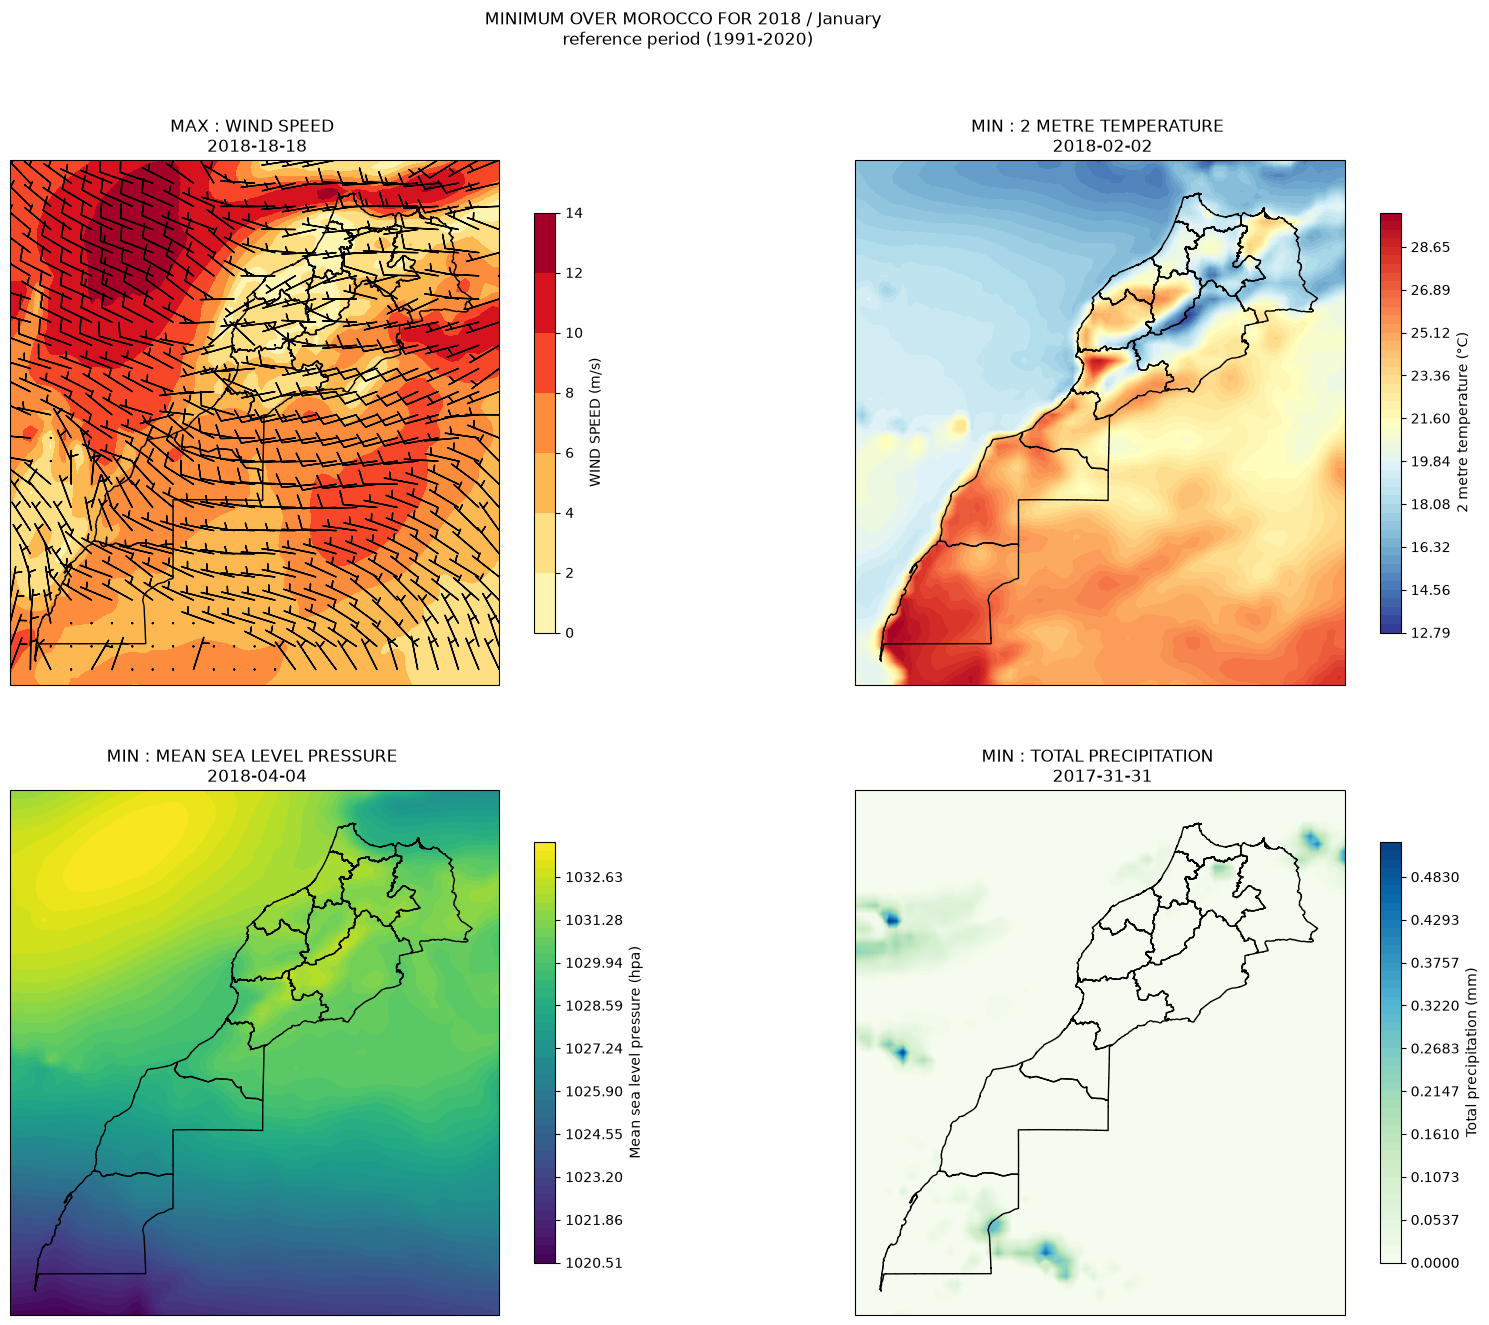

In [11]:
Plot.plot_max_days(daily_stats , "min" , year , month , output_dir)

# III-3 ANOMALY 

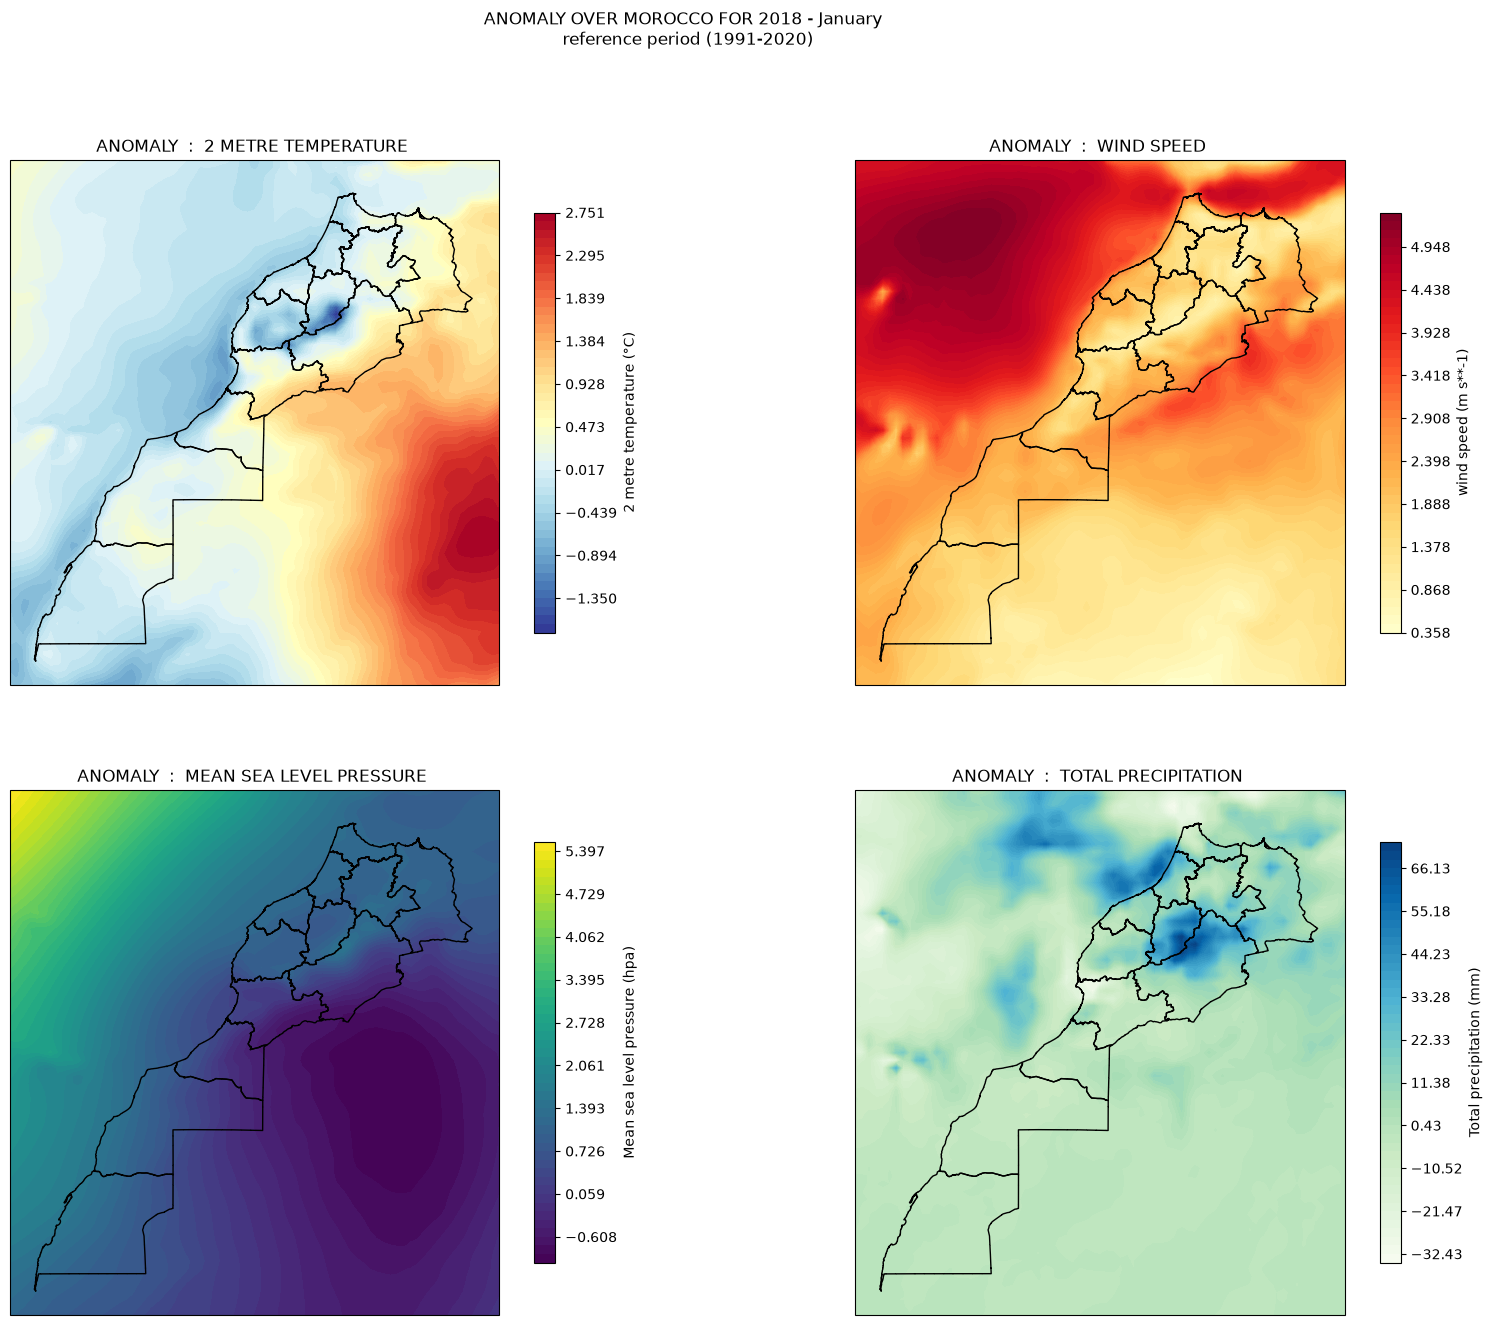

In [12]:
Plot.plot_anomaly(anomaly , year , month , output_dir)